In [1]:
!pip install -q geopandas folium shapely requests pandas matplotlib scikit-learn

import geopandas as gpd
import folium, shapely, requests, pandas as pd

print("geopandas:", gpd.__version__)
print("folium:", folium.__version__)
print("Ambiente OK ✅")

geopandas: 1.1.4
folium: 0.20.0
Ambiente OK ✅


In [2]:
import os, zipfile, requests
import geopandas as gpd

os.makedirs("dados", exist_ok=True)

# Endereço que segue a estrutura de pastas do IBGE; o nome do arquivo é uma suposição
URL = ("https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/"
       "malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/"
       "bairros/shp/UF/RJ_bairros_CD2022.zip")

r = requests.get(URL, timeout=120)
print("Status:", r.status_code)

if r.status_code == 200:
    with open("dados/rj_bairros.zip", "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile("dados/rj_bairros.zip") as z:
        z.extractall("dados/rj_bairros")
    print(os.listdir("dados/rj_bairros"))

Status: 200
['RJ_bairros_CD2022.shx', 'RJ_bairros_CD2022.prj', 'RJ_bairros_CD2022.cpg', 'RJ_bairros_CD2022.dbf', 'RJ_bairros_CD2022.shp']


In [3]:
import glob
shp = glob.glob("dados/rj_bairros/**/*.shp", recursive=True)[0]
gdf = gpd.read_file(shp)

print("Colunas:", list(gdf.columns))
print("CRS:", gdf.crs)
print("Total de feições no RJ (estado):", len(gdf))
gdf.head(3)

Colunas: ['CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_BAIRRO', 'NM_BAIRRO', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'geometry']
CRS: EPSG:4674
Total de feições no RJ (estado): 1509


,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,NM_MUN,CD_DIST,NM_DIST,CD_SUBDIST,NM_SUBDIST,CD_BAIRRO,NM_BAIRRO,CD_RGINT,NM_RGINT,CD_RGI,NM_RGI,CD_CONCURB,NM_CONCURB,geometry
0,3,Sudeste,33,Rio de Janeiro,3300100,Angra dos Reis,330010005,Angra dos Reis,33001000500,None,3300100110,Praia do Jardim,3301,Rio de Janeiro,330002,Angra dos Reis,3300100,Angra dos Reis,"POLYGON ((-44.29608 -23.01014, -44.2961 -23.01..."
1,3,Sudeste,33,Rio de Janeiro,3300100,Angra dos Reis,330010005,Angra dos Reis,33001000500,None,3300100036,Portogalo,3301,Rio de Janeiro,330002,Angra dos Reis,3300100,Angra dos Reis,"POLYGON ((-44.19451 -23.05451, -44.1948 -23.05..."
2,3,Sudeste,33,Rio de Janeiro,3300100,Angra dos Reis,330010005,Angra dos Reis,33001000500,None,3300100009,Caputera II,3301,Rio de Janeiro,330002,Angra dos Reis,3300100,Angra dos Reis,"POLYGON ((-44.2182 -22.98174, -44.21806 -22.98..."


Bairros no município do Rio: 162
Área total (km²): 1200.1
['Vaz Lobo', 'Pedra de Guaratiba', 'Joá', 'Grajaú', 'Méier', 'Ribeira', 'Tauá', 'Catete', 'Vila Militar', 'Cidade de Deus']


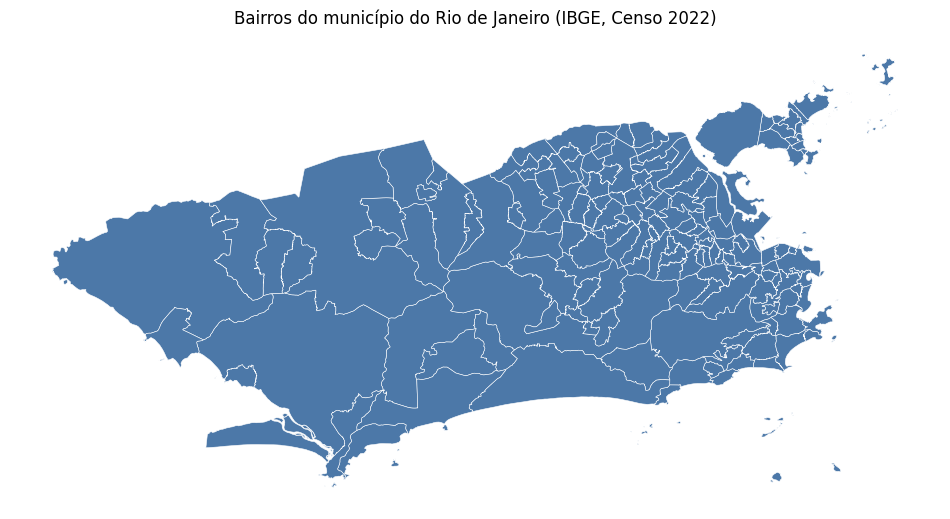

Salvo em saida/rio_bairros.gpkg ✅


In [4]:
import matplotlib.pyplot as plt

rio = gdf[gdf["CD_MUN"].astype(str) == "3304557"].copy()

rio = rio[["CD_BAIRRO", "NM_BAIRRO", "NM_DIST", "geometry"]].reset_index(drop=True)

rio = rio.to_crs(epsg=31983)
rio["area_km2"] = rio.geometry.area / 1e6

print("Bairros no município do Rio:", len(rio))
print("Área total (km²):", round(rio["area_km2"].sum(), 1))
print(rio["NM_BAIRRO"].head(10).tolist())

fig, ax = plt.subplots(figsize=(12, 8))
rio.plot(ax=ax, edgecolor="white", linewidth=0.4, color="#4c78a8")
ax.set_title("Bairros do município do Rio de Janeiro (IBGE, Censo 2022)")
ax.axis("off")
plt.show()

os.makedirs("saida", exist_ok=True)
rio.to_file("saida/rio_bairros.gpkg", driver="GPKG")
print("Salvo em saida/rio_bairros.gpkg ✅")

In [5]:
import re, requests

BASE = "https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios/"

r = requests.get(BASE, timeout=60)
print("Status:", r.status_code)

if r.status_code == 200:
    links = re.findall(r'href="([^"?/][^"]*)"', r.text)
    for l in links:
        print(l)

Status: 200
https://www.ibge.gov.br/
Agregados_por_Bairro_csv/
Agregados_por_Bairro_xlsx/
Agregados_por_Distrito_csv/
Agregados_por_Distrito_xlsx/
Agregados_por_Municipio_csv/
Agregados_por_Municipio_xlsx/
Agregados_por_Setor_csv/
Agregados_por_Setor_xlsx/
Agregados_por_SubDistrito_csv/
Agregados_por_SubDistrito_xlsx/
dicionario_de_dados_agregados_por_setores_censitarios_20260520.xlsx
malha_com_atributos/
https://www.ibge.gov.br/
http://www.facebook.com/ibgeoficial
https://instagram.com/ibgeoficial
https://www.tiktok.com/@ibgeoficial
https://twitter.com/ibgecomunica
http://www.youtube.com/ibgeoficial


In [6]:
URL_BAIRRO = BASE + "Agregados_por_Bairro_csv/"

r = requests.get(URL_BAIRRO, timeout=60)
print("Status:", r.status_code)

if r.status_code == 200:
    links = re.findall(r'href="([^"?/][^"]*)"', r.text)
    for l in links:
        if "ibge.gov.br" not in l and "facebook" not in l and "instagram" not in l \
           and "tiktok" not in l and "twitter" not in l and "youtube" not in l:
            print(l)

Status: 200
Agregados_por_bairros_alfabetizacao_BR.zip
Agregados_por_bairros_basico_BR_20260520.zip
Agregados_por_bairros_caracteristicas_domicilio1_BR.zip
Agregados_por_bairros_caracteristicas_domicilio2_BR_20250417.zip
Agregados_por_bairros_caracteristicas_domicilio3_BR_20250417.zip
Agregados_por_bairros_cor_ou_raca_BR.zip
Agregados_por_bairros_demografia_BR.zip
Agregados_por_bairros_domicilios_indigenas_BR.zip
Agregados_por_bairros_domicilios_quilombolas_BR.zip
Agregados_por_bairros_obitos_BR.zip
Agregados_por_bairros_parentesco_BR.zip
Agregados_por_bairros_pessoas_indigenas_BR.zip
Agregados_por_bairros_pessoas_quilombolas_BR.zip


In [7]:
import io

arquivos = [
    "Agregados_por_bairros_basico_BR_20260520.zip",
    "Agregados_por_bairros_demografia_BR.zip",
]

os.makedirs("dados/censo", exist_ok=True)

for nome in arquivos:
    r = requests.get(URL_BAIRRO + nome, timeout=300)
    print(nome, "→ Status:", r.status_code, "| Tamanho (MB):", round(len(r.content)/1e6, 2))
    if r.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall("dados/censo")

print(os.listdir("dados/censo"))

Agregados_por_bairros_basico_BR_20260520.zip → Status: 200 | Tamanho (MB): 0.72
Agregados_por_bairros_demografia_BR.zip → Status: 200 | Tamanho (MB): 1.32
['Agregados_por_bairros_basico_BR.csv', 'Agregados_por_bairros_demografia_BR.csv']


In [8]:
import pandas as pd

for f in sorted(os.listdir("dados/censo")):
    if f.lower().endswith(".csv"):
        try:
            df = pd.read_csv(f"dados/censo/{f}", sep=";", encoding="utf-8", nrows=3)
        except UnicodeDecodeError:
            df = pd.read_csv(f"dados/censo/{f}", sep=";", encoding="latin1", nrows=3)
        print("\n====", f)
        print("Nº de colunas:", df.shape[1])
        print(list(df.columns)[:30])


==== Agregados_por_bairros_basico_BR.csv
Nº de colunas: 32
['CD_BAIRRO', 'NM_BAIRRO', 'CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_NU', 'NM_NU', 'CD_AGLOM', 'NM_AGLOM', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'AREA_KM2', 'v0001', 'v0002', 'v0003', 'v0004', 'v0005', 'v0006', 'v0007']

==== Agregados_por_bairros_demografia_BR.csv
Nº de colunas: 38
['CD_BAIRRO', 'NM_BAIRRO', 'V01006', 'V01007', 'V01008', 'V01009', 'V01010', 'V01011', 'V01012', 'V01013', 'V01014', 'V01015', 'V01016', 'V01017', 'V01018', 'V01019', 'V01020', 'V01021', 'V01022', 'V01023', 'V01024', 'V01025', 'V01026', 'V01027', 'V01028', 'V01029', 'V01030', 'V01031', 'V01032', 'V01033']


In [9]:
nome_dic = "dicionario_de_dados_agregados_por_setores_censitarios_20260520.xlsx"
r = requests.get(BASE + nome_dic, timeout=120)
print("Dicionário → Status:", r.status_code)

with open(f"dados/{nome_dic}", "wb") as f:
    f.write(r.content)

xls = pd.ExcelFile(f"dados/{nome_dic}")
print("Abas:", xls.sheet_names)

for aba in xls.sheet_names:
    d = xls.parse(aba, header=None, nrows=6)
    print(f"\n==== Aba: {aba} | formato: {xls.parse(aba, header=None).shape}")
    print(d.to_string(max_colwidth=50))

basico = pd.read_csv("dados/censo/Agregados_por_bairros_basico_BR.csv", sep=";",
                     encoding="utf-8", dtype={"CD_BAIRRO": str, "CD_MUN": str})
basico_rio = basico[basico["CD_MUN"] == "3304557"]

print("\nBairros do Rio no Censo (CSV):", len(basico_rio))
print("Bairros do Rio no mapa:", len(rio))

chaves_mapa = set(rio["CD_BAIRRO"].astype(str))
chaves_censo = set(basico_rio["CD_BAIRRO"].astype(str))
print("Em comum:", len(chaves_mapa & chaves_censo))
print("Só no mapa:", len(chaves_mapa - chaves_censo))
print("Só no Censo:", len(chaves_censo - chaves_mapa))

Dicionário → Status: 200
Abas: ['Dicionário Básico', 'Siglas Básico', 'Dicionário não PCT', 'Dicionário PCT - Indígenas', 'Dicionário PCT - Quilombolas']

==== Aba: Dicionário Básico | formato: (10, 3)
        0         1                                                  2
0    Tema  Variável                                          Descrição
1  Básico     V0001                                   Total de pessoas
2  Básico     V0002  Total de Domicílios (DPPO + DPPV + DPPUO + DPI...
3  Básico     V0003  Total de Domicílios Particulares (DPPO + DPPV ...
4  Básico     V0004        Total de Domicílios Coletivos (DCCM + DCSM)
5  Básico     V0005  Média de moradores em Domicílios Particulares ...

==== Aba: Siglas Básico | formato: (8, 2)
       0                                                 1
0  Sigla                                         Descrição
1   DPPO           Domicílio Particular Permanente Ocupado
2   DPIO          Domicílio Particular Improvisado Ocupado
3   DPPV              

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe1 in position 18: invalid continuation byte

In [10]:
basico = pd.read_csv("dados/censo/Agregados_por_bairros_basico_BR.csv", sep=";",
                     encoding="latin1", dtype={"CD_BAIRRO": str, "CD_MUN": str})
basico_rio = basico[basico["CD_MUN"] == "3304557"]

print("Bairros do Rio no Censo (CSV):", len(basico_rio))
print("Bairros do Rio no mapa:", len(rio))

chaves_mapa = set(rio["CD_BAIRRO"].astype(str))
chaves_censo = set(basico_rio["CD_BAIRRO"].astype(str))
print("Em comum:", len(chaves_mapa & chaves_censo))
print("Só no mapa:", len(chaves_mapa - chaves_censo))
print("Só no Censo:", len(chaves_censo - chaves_mapa))

dic_basico = xls.parse("Dicionário Básico")
print("\n=== DICIONÁRIO BÁSICO ===")
print(dic_basico.to_string(max_colwidth=90))

dic = xls.parse("Dicionário não PCT")
print("\nTemas disponíveis:")
print(dic["Tema"].value_counts().to_string())

print("\n=== Variáveis com 'rendimento' ou 'renda' ===")
print(dic[dic["Descrição"].str.contains("rendimento|renda", case=False, na=False)]
      [["Tema", "Variável", "Descrição"]].head(15).to_string(max_colwidth=80))

print("\n=== Tema Demografia: primeiras 40 variáveis ===")
demo = dic[dic["Tema"].str.contains("Demografia", case=False, na=False)]
print(demo[["Variável", "Descrição"]].head(40).to_string(max_colwidth=90))

Bairros do Rio no Censo (CSV): 162
Bairros do Rio no mapa: 162
Em comum: 162
Só no mapa: 0
Só no Censo: 0

=== DICIONÁRIO BÁSICO ===
     Tema Variável                                                                                  Descrição
0  Básico    V0001                                                                           Total de pessoas
1  Básico    V0002                             Total de Domicílios (DPPO + DPPV + DPPUO + DPIO + DCCM + DCSM)
2  Básico    V0003                              Total de Domicílios Particulares (DPPO + DPPV + DPPUO + DPIO)
3  Básico    V0004                                                Total de Domicílios Coletivos (DCCM + DCSM)
4  Básico    V0005  Média de moradores em Domicílios Particulares Ocupados (Total pessoas em Domicílios Pa...
5  Básico    V0006  Percentual de Domicílios Particulares Ocupados Imputados (Total DPO imputados / Total ...
6  Básico    V0007                                    Total de Domicílios Particulares Ocupados (

Bairros: 162 | com NaN em pop_total: 0
População total do Rio: 6211223
Público-alvo (20-49): 2743430 (44.2%)

Top 10 em população:
               NM_BAIRRO  pop_total  pop_alvo_20_49
            Campo Grande     352356          155054
              Santa Cruz     249130          113434
             Jacarepaguá     217462          109314
                   Bangu     209302           92611
                Realengo     167027           71898
               Guaratiba     159888           75181
         Barra da Tijuca     151603           61461
                  Tijuca     142909           57877
Recreio dos Bandeirantes     140437           68832
              Copacabana     128919           53537

Top 10 em densidade de público-alvo (hab/km²):
     NM_BAIRRO  dens_alvo
       Rocinha    26016.0
   Jacarezinho    17217.0
        Catete    15583.0
          Maré    14252.0
    Copacabana    13031.0
          Lapa    12780.0
       Estácio    12433.0
      Flamengo    10914.0
 Gardênia Azul 

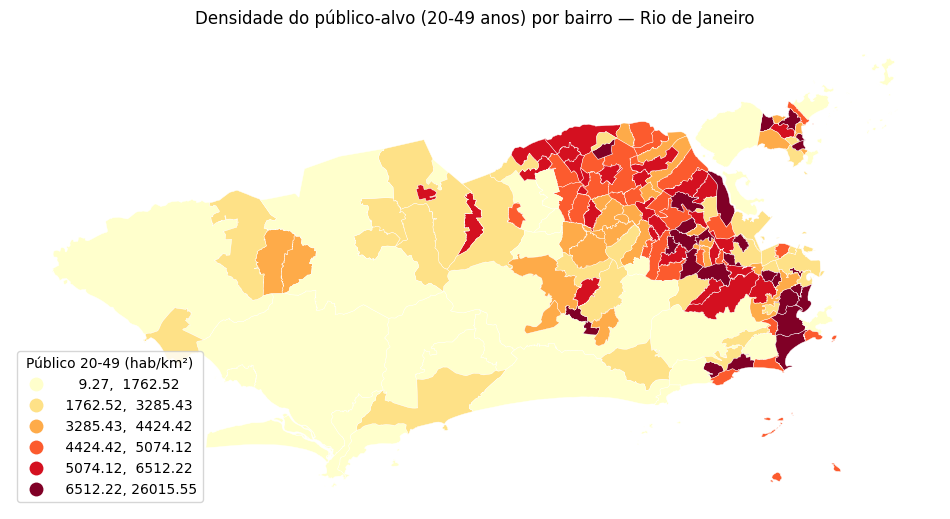

Salvo ✅


In [11]:
def ler(nome):
    return pd.read_csv(f"dados/censo/{nome}", sep=";", encoding="latin1",
                       dtype={"CD_BAIRRO": str, "CD_MUN": str})

basico = ler("Agregados_por_bairros_basico_BR.csv")
demo   = ler("Agregados_por_bairros_demografia_BR.csv")

basico_rio = basico[basico["CD_MUN"] == "3304557"]
demo_rio   = demo[demo["CD_BAIRRO"].isin(basico_rio["CD_BAIRRO"])]

faixas_alvo = ["V01035", "V01036", "V01037", "V01038"]   # 20-24, 25-29, 30-39, 40-49

b = basico_rio[["CD_BAIRRO", "v0001", "v0002", "v0007"]].rename(
    columns={"v0001": "pop_total", "v0002": "domicilios", "v0007": "dom_ocupados"})

d = demo_rio[["CD_BAIRRO"] + faixas_alvo].copy()

for col in b.columns[1:]:
    b[col] = pd.to_numeric(b[col], errors="coerce")
for col in faixas_alvo:
    d[col] = pd.to_numeric(d[col], errors="coerce")

d["pop_alvo_20_49"] = d[faixas_alvo].sum(axis=1)
tabela = b.merge(d[["CD_BAIRRO", "pop_alvo_20_49"]], on="CD_BAIRRO", how="left")

rio_dados = rio.merge(tabela, on="CD_BAIRRO", how="left")
rio_dados["pct_alvo"]      = rio_dados["pop_alvo_20_49"] / rio_dados["pop_total"] * 100
rio_dados["dens_pop"]      = rio_dados["pop_total"] / rio_dados["area_km2"]
rio_dados["dens_alvo"]     = rio_dados["pop_alvo_20_49"] / rio_dados["area_km2"]

print("Bairros:", len(rio_dados), "| com NaN em pop_total:", rio_dados["pop_total"].isna().sum())
print("População total do Rio:", int(rio_dados["pop_total"].sum()))
print("Público-alvo (20-49):", int(rio_dados["pop_alvo_20_49"].sum()),
      f"({rio_dados['pop_alvo_20_49'].sum()/rio_dados['pop_total'].sum()*100:.1f}%)")

print("\nTop 10 em população:")
print(rio_dados.nlargest(10, "pop_total")[["NM_BAIRRO", "pop_total", "pop_alvo_20_49"]].to_string(index=False))

print("\nTop 10 em densidade de público-alvo (hab/km²):")
print(rio_dados.nlargest(10, "dens_alvo")[["NM_BAIRRO", "dens_alvo"]].round(0).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
rio_dados.plot(column="dens_alvo", cmap="YlOrRd", scheme="quantiles", k=6,
               legend=True, edgecolor="white", linewidth=0.3, ax=ax,
               legend_kwds={"title": "Público 20-49 (hab/km²)", "loc": "lower left"})
ax.set_title("Densidade do público-alvo (20-49 anos) por bairro — Rio de Janeiro")
ax.axis("off")
plt.show()

rio_dados.to_file("saida/rio_bairros_dados.gpkg", driver="GPKG")
rio_dados.drop(columns="geometry").to_csv("saida/rio_bairros_dados.csv", index=False)
print("Salvo ✅")

In [12]:
def listar(url):
    r = requests.get(url, timeout=60)
    print(url, "→ Status:", r.status_code)
    if r.status_code == 200:
        links = re.findall(r'href="([^"?/][^"]*/?)"', r.text)
        for l in links:
            if not l.startswith("http"):
                print("  ", l)
    print()

listar("https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/")

https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/ → Status: 200
   Agregados_por_Setores_Censitarios/
   Agregados_por_Setores_Censitarios_Caracteristicas_urbanisticas_do_entorno_dos_domicilios/
   Agregados_por_Setores_Censitarios_Registro_de_Nascimento/
   Agregados_por_Setores_Censitarios_Rendimento_do_Responsavel/
   Agregados_por_Setores_Censitarios_preliminares/
   Dados_percentuais_das_Caracteristicas_urbanisticas_do_entorno_dos_domicilios/
   Etnias_e_Linguas_Indigenas_principais_caracteristicas_sociodemograficas_Resultados_do_universo/
   Favelas_e_comunidades_urbanas_Caracteristicas_do_entorno/
   Favelas_e_comunidades_urbanas_Resultados_do_universo/
   Indigenas_Primeiros_resultados_do_universo/
   Indigenas_alfabetizacao_registros_de_nascimento_caracteristicas_dos_domicilios_Resultados_do_universo/
   Indigenas_principais_caracteristicas_pessoas_domicilios_urbana_rural_Resultados_do_universo/
   Microdados_e_Areas_de_Ponderacao/
   Mulheres/
   Populacao_e_domicilios_P

In [13]:
BASE_RENDA = ("https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/"
              "Agregados_por_Setores_Censitarios_Rendimento_do_Responsavel/")

listar(BASE_RENDA)

https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios_Rendimento_do_Responsavel/ → Status: 200
   Agregados_por_bairros_renda_responsavel_BR_20260508_csv.zip
   Agregados_por_bairros_renda_responsavel_BR_20260508_xlsx.zip
   Agregados_por_distritos_renda_responsavel_BR_20260508_csv.zip
   Agregados_por_distritos_renda_responsavel_BR_20260508_xlsx.zip
   Agregados_por_municipios_renda_responsavel_BR_20260508_csv.zip
   Agregados_por_municipios_renda_responsavel_BR_20260508_xlsx.zip
   Agregados_por_setores_renda_responsavel_BR_20260508_csv.zip
   Agregados_por_setores_renda_responsavel_BR_20260508_xlsx.zip
   Agregados_por_subdistritos_renda_responsavel_BR_20260508_csv.zip
   Agregados_por_subdistritos_renda_responsavel_BR_20260508_xlsx.zip
   dicionario_de_dados_renda_responsavel_20260508.xlsx



In [14]:
nome_zip = "Agregados_por_bairros_renda_responsavel_BR_20260508_csv.zip"
r = requests.get(BASE_RENDA + nome_zip, timeout=300)
print("Renda bairros → Status:", r.status_code, "| MB:", round(len(r.content)/1e6, 2))

os.makedirs("dados/renda", exist_ok=True)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("dados/renda")
print(os.listdir("dados/renda"))

nome_dic_renda = "dicionario_de_dados_renda_responsavel_20260508.xlsx"
r = requests.get(BASE_RENDA + nome_dic_renda, timeout=120)
print("Dicionário → Status:", r.status_code)
with open(f"dados/{nome_dic_renda}", "wb") as f:
    f.write(r.content)

xls_r = pd.ExcelFile(f"dados/{nome_dic_renda}")
print("Abas:", xls_r.sheet_names)
for aba in xls_r.sheet_names:
    d = xls_r.parse(aba)
    print(f"\n==== Aba: {aba} | formato: {d.shape}")
    print(d.head(40).to_string(max_colwidth=100))

arq = [f for f in os.listdir("dados/renda") if f.lower().endswith(".csv")][0]
renda = pd.read_csv(f"dados/renda/{arq}", sep=";", encoding="latin1",
                    dtype={"CD_BAIRRO": str, "CD_MUN": str}, nrows=3)
print("\nColunas do CSV de renda:", list(renda.columns))
print(renda.head(3).to_string())

Renda bairros → Status: 200 | MB: 0.5
['Agregados_por_bairros_renda_responsavel_BR.csv']
Dicionário → Status: 200
Abas: ['Dicionário Renda Responsável']

==== Aba: Dicionário Renda Responsável | formato: (6, 3)
                   Tema Variável                                                                                            Descrição
0  Renda do Responsável   V06001                                 Pessoas responsáveis em domicílios particulares permanentes ocupados
1  Renda do Responsável   V06002                                            Moradores em domicílios particulares permanentes ocupados
2  Renda do Responsável   V06003                     Variância do número de moradores em domicílios particulares permanentes ocupados
3  Renda do Responsável   V06004  Valor do rendimento nominal médio mensal das pessoas responsáveis com rendimentos por domicílios...
4  Renda do Responsável   V06005  Variância do rendimento nominal mensal das pessoas responsáveis com rendimentos por d

Bairros do Rio no arquivo de renda: 162
Sem renda mediana (NaN): 0

Mediana da renda mediana (bairros): 2000

Top 10 renda mediana:
      NM_BAIRRO  renda_mediana  renda_mediana_sm
          Lagoa        15000.0              12.4
         Leblon        12000.0               9.9
Barra da Tijuca        10001.0               8.3
        Humaitá        10000.0               8.3
    São Conrado        10000.0               8.3
           Urca        10000.0               8.3
Jardim Botânico        10000.0               8.3
        Ipanema        10000.0               8.3
          Gávea         9000.0               7.4
            Joá         8000.0               6.6

Bottom 10 renda mediana:
         NM_BAIRRO  renda_mediana  renda_mediana_sm
           Grumari          600.0               0.5
    Cidade de Deus         1212.0               1.0
              Maré         1212.0               1.0
           Benfica         1212.0               1.0
         Mangueira         1212.0          

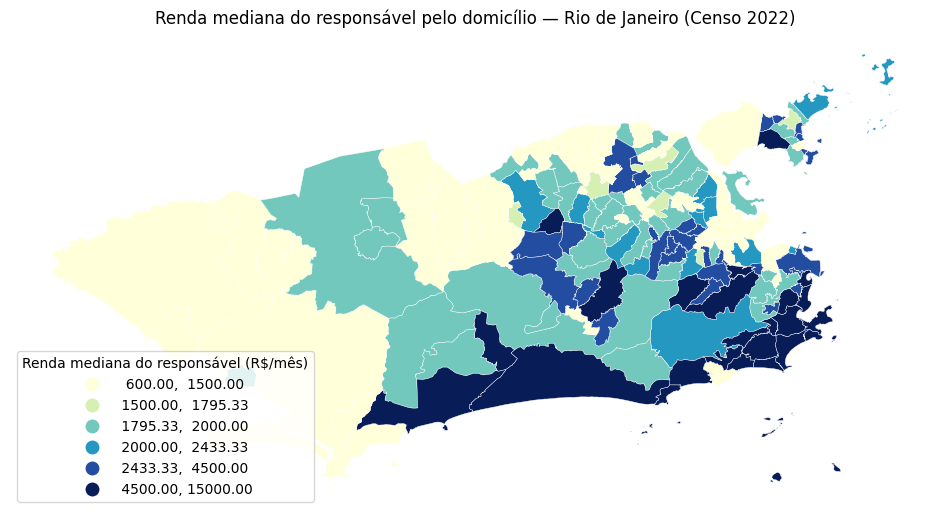

Salvo ✅


In [15]:
renda = pd.read_csv("dados/renda/Agregados_por_bairros_renda_responsavel_BR.csv",
                    sep=";", encoding="latin1", decimal=",",
                    dtype={"CD_BAIRRO": str})

renda = renda[renda["CD_BAIRRO"].isin(rio_dados["CD_BAIRRO"])]
renda = renda[["CD_BAIRRO", "V06001", "V06004", "V06006"]].rename(columns={
    "V06001": "responsaveis",
    "V06004": "renda_media",
    "V06006": "renda_mediana"})

for c in ["responsaveis", "renda_media", "renda_mediana"]:
    renda[c] = pd.to_numeric(renda[c], errors="coerce")

print("Bairros do Rio no arquivo de renda:", len(renda))
print("Sem renda mediana (NaN):", renda["renda_mediana"].isna().sum())

SM_2022 = 1212
rio_dados = rio_dados.drop(columns=[c for c in ["responsaveis", "renda_media", "renda_mediana"]
                                    if c in rio_dados.columns]) \
                     .merge(renda, on="CD_BAIRRO", how="left")

rio_dados["renda_mediana_sm"] = rio_dados["renda_mediana"] / SM_2022
rio_dados["massa_renda_mi"] = rio_dados["responsaveis"] * rio_dados["renda_media"] / 1e6  # R$ milhões/mês (aprox.)

print("\nMediana da renda mediana (bairros):", round(rio_dados["renda_mediana"].median()))
print("\nTop 10 renda mediana:")
print(rio_dados.nlargest(10, "renda_mediana")[["NM_BAIRRO", "renda_mediana", "renda_mediana_sm"]]
      .round(1).to_string(index=False))
print("\nBottom 10 renda mediana:")
print(rio_dados.nsmallest(10, "renda_mediana")[["NM_BAIRRO", "renda_mediana", "renda_mediana_sm"]]
      .round(1).to_string(index=False))
print("\nTop 10 massa de renda (R$ mi/mês):")
print(rio_dados.nlargest(10, "massa_renda_mi")[["NM_BAIRRO", "massa_renda_mi"]]
      .round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
rio_dados.plot(column="renda_mediana", cmap="YlGnBu", scheme="quantiles", k=6,
               legend=True, edgecolor="white", linewidth=0.3, ax=ax,
               missing_kwds={"color": "lightgrey", "label": "Sem dado"},
               legend_kwds={"title": "Renda mediana do responsável (R$/mês)", "loc": "lower left"})
ax.set_title("Renda mediana do responsável pelo domicílio — Rio de Janeiro (Censo 2022)")
ax.axis("off")
plt.show()

rio_dados.to_file("saida/rio_bairros_dados.gpkg", driver="GPKG")
rio_dados.drop(columns="geometry").to_csv("saida/rio_bairros_dados.csv", index=False)
print("Salvo ✅")

Tentativa 1 | https://overpass-api.de/api/interpreter → Status: 200
Elementos retornados: 50

Lojas dentro do município do Rio: 40
marca
Renner       16
C&A          12
Riachuelo     9
Farm          3

Bairros com mais lojas:
NM_BAIRRO
Centro                      6
Barra da Tijuca             5
Jacarepaguá                 3
Campo Grande                3
Cachambi                    3
Ipanema                     3
Madureira                   3
Recreio dos Bandeirantes    2
Copacabana                  2
Botafogo                    2

Bairros com pelo menos 1 loja: 17 de 162


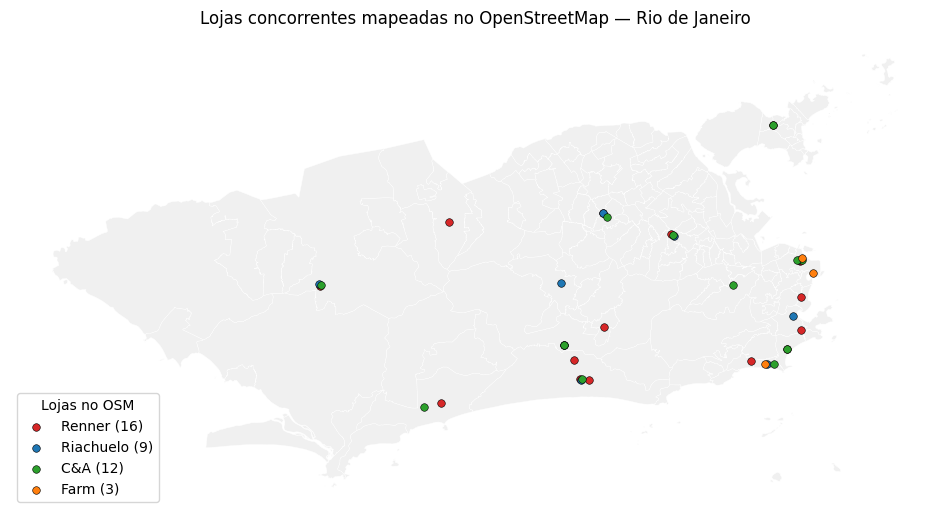

Salvo ✅


In [20]:
import time, json

# --- 1) Retângulo do Rio (sul, oeste, norte, leste) ---
minx, miny, maxx, maxy = rio_dados.to_crs(4326).total_bounds
bbox = f"{miny},{minx},{maxy},{maxx}"

regex = r"^(Lojas )?Renner|Riachuelo|^C&A|^Farm( Rio)?$"
query = f"""
[out:json][timeout:120];
(
  nwr["shop"]["name"~"{regex}",i]({bbox});
  nwr["shop"]["brand"~"{regex}",i]({bbox});
);
out center tags;
"""

# --- 2) Chamar a Overpass API (com User-Agent, espera e servidor reserva) ---
headers = {
    "User-Agent": "white-spots-iconic-rj/1.0 (projeto de portfolio; analise de expansao de varejo)",
    "Accept": "application/json",
}
servidores = ["https://overpass-api.de/api/interpreter",
              "https://overpass.kumi.systems/api/interpreter",
              "https://maps.mail.ru/osm/tools/overpass/api/interpreter"]

dados = None
for tentativa in range(4):
    for srv in servidores:
        try:
            r = requests.post(srv, data={"data": query}, headers=headers, timeout=180)
            print(f"Tentativa {tentativa+1} | {srv} → Status: {r.status_code}")
            if r.status_code == 200:
                dados = r.json()
                break
        except Exception as e:
            print(srv, "→ erro:", e)
    if dados:
        break
    espera = 15 * (tentativa + 1)
    print(f"Aguardando {espera}s antes de tentar de novo...")
    time.sleep(espera)

if not dados:
    raise RuntimeError("Nenhum servidor respondeu. Espere alguns minutos e execute de novo.")

print("Elementos retornados:", len(dados["elements"]))

# --- 3) Montar tabela de lojas ---
def classificar(tags):
    txt = (tags.get("brand", "") + " " + tags.get("name", "")).lower()
    if "renner" in txt: return "Renner"
    if "riachuelo" in txt: return "Riachuelo"
    if "c&a" in txt: return "C&A"
    if txt.strip().startswith("farm") or " farm" in txt: return "Farm"
    return None

linhas = []
for el in dados["elements"]:
    lat = el.get("lat") or el.get("center", {}).get("lat")
    lon = el.get("lon") or el.get("center", {}).get("lon")
    tags = el.get("tags", {})
    marca = classificar(tags)
    if lat and lon and marca:
        linhas.append({"osm_id": f'{el["type"]}/{el["id"]}', "marca": marca,
                       "nome": tags.get("name", ""), "lat": lat, "lon": lon})

lojas = gpd.GeoDataFrame(linhas,
        geometry=gpd.points_from_xy([l["lon"] for l in linhas], [l["lat"] for l in linhas]),
        crs=4326).to_crs(rio_dados.crs)

# --- 4) Manter só lojas dentro do município e descobrir o bairro de cada uma ---
lojas = gpd.sjoin(lojas, rio_dados[["CD_BAIRRO", "NM_BAIRRO", "geometry"]],
                  how="inner", predicate="within").drop(columns="index_right")

# remove duplicatas óbvias (mesma marca, a menos de 30 m uma da outra)
lojas = lojas.sort_values("osm_id").reset_index(drop=True)
buf = lojas.copy(); buf["geometry"] = buf.buffer(30)
dup = gpd.sjoin(lojas, buf[["marca", "geometry"]], predicate="within")
dup = dup[(dup["marca_left"] == dup["marca_right"]) & (dup.index != dup["index_right"])]
remover = set(min(i, j) for i, j in zip(dup.index, dup["index_right"]) if i != j)
lojas = lojas.drop(index=list(remover)).reset_index(drop=True)

# --- 5) Conferências ---
print("\nLojas dentro do município do Rio:", len(lojas))
print(lojas["marca"].value_counts().to_string())
print("\nBairros com mais lojas:")
print(lojas.groupby("NM_BAIRRO").size().sort_values(ascending=False).head(10).to_string())
print("\nBairros com pelo menos 1 loja:", lojas["CD_BAIRRO"].nunique(), "de", len(rio_dados))

# --- 6) Mapa ---
cores = {"Renner": "#d62728", "Riachuelo": "#1f77b4", "C&A": "#2ca02c", "Farm": "#ff7f0e"}
fig, ax = plt.subplots(figsize=(12, 8))
rio_dados.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.3)
for marca, cor in cores.items():
    sub = lojas[lojas["marca"] == marca]
    sub.plot(ax=ax, color=cor, markersize=30, label=f"{marca} ({len(sub)})", edgecolor="black", linewidth=0.4)
ax.legend(title="Lojas no OSM", loc="lower left")
ax.set_title("Lojas concorrentes mapeadas no OpenStreetMap — Rio de Janeiro")
ax.axis("off")
plt.show()

# --- 7) Salvar ---
lojas.to_file("saida/lojas_concorrentes.gpkg", driver="GPKG")
lojas.drop(columns="geometry").to_csv("saida/lojas_concorrentes.csv", index=False)
print("Salvo ✅")

Tentativa 1 | https://overpass-api.de/api/interpreter → Status: 504
Tentativa 1 | https://overpass.kumi.systems/api/interpreter → Status: 504
Tentativa 1 | https://maps.mail.ru/osm/tools/overpass/api/interpreter → Status: 504
Tentativa 2 | https://overpass-api.de/api/interpreter → Status: 200

Shoppings no município do Rio: 186
                                                                                                                        nome                NM_BAIRRO
                                                                                                      Boulevard Rio Shopping                  Andaraí
                                                                                                             ParkJacarepaguá                     Anil
                                                                                                    Centro Comercial Popular                    Bangu
                                                                      

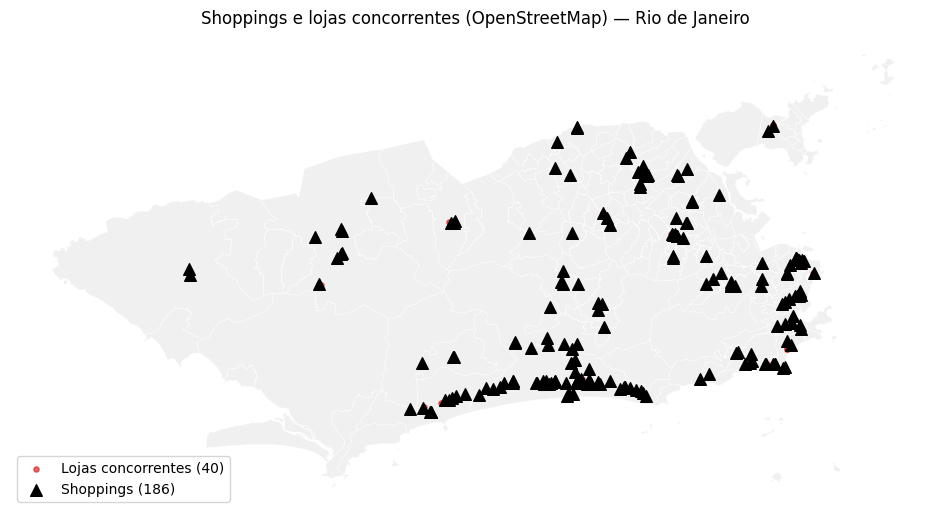

Salvo ✅


In [21]:
# --- 1) Buscar shoppings no retângulo do Rio (reaproveita bbox, headers e servidores) ---
query_malls = f"""
[out:json][timeout:120];
(
  nwr["shop"="mall"]({bbox});
);
out center tags;
"""

dados_malls = None
for tentativa in range(4):
    for srv in servidores:
        try:
            r = requests.post(srv, data={"data": query_malls}, headers=headers, timeout=180)
            print(f"Tentativa {tentativa+1} | {srv} → Status: {r.status_code}")
            if r.status_code == 200:
                dados_malls = r.json()
                break
        except Exception as e:
            print(srv, "→ erro:", e)
    if dados_malls:
        break
    time.sleep(15 * (tentativa + 1))

if not dados_malls:
    raise RuntimeError("Nenhum servidor respondeu. Espere alguns minutos e execute de novo.")

# --- 2) Montar tabela ---
linhas = []
for el in dados_malls["elements"]:
    lat = el.get("lat") or el.get("center", {}).get("lat")
    lon = el.get("lon") or el.get("center", {}).get("lon")
    tags = el.get("tags", {})
    if lat and lon:
        linhas.append({"osm_id": f'{el["type"]}/{el["id"]}',
                       "nome": tags.get("name", "(sem nome)"),
                       "lat": lat, "lon": lon})

malls = gpd.GeoDataFrame(linhas,
        geometry=gpd.points_from_xy([l["lon"] for l in linhas], [l["lat"] for l in linhas]),
        crs=4326).to_crs(rio_dados.crs)

# --- 3) Só dentro do município, com o bairro de cada um ---
malls = gpd.sjoin(malls, rio_dados[["CD_BAIRRO", "NM_BAIRRO", "geometry"]],
                  how="inner", predicate="within").drop(columns="index_right")

# remove duplicatas (mesmo nome a menos de 200 m)
malls = malls.sort_values("osm_id").reset_index(drop=True)
buf = malls.copy(); buf["geometry"] = buf.buffer(200)
dup = gpd.sjoin(malls, buf[["nome", "geometry"]], predicate="within")
dup = dup[(dup["nome_left"] == dup["nome_right"]) & (dup.index != dup["index_right"])]
remover = set(min(i, j) for i, j in zip(dup.index, dup["index_right"]) if i != j)
malls = malls.drop(index=list(remover)).reset_index(drop=True)

# --- 4) Conferências ---
print("\nShoppings no município do Rio:", len(malls))
print(malls[["nome", "NM_BAIRRO"]].sort_values("NM_BAIRRO").to_string(index=False))

# --- 5) Mapa: shoppings + lojas concorrentes ---
fig, ax = plt.subplots(figsize=(12, 8))
rio_dados.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.3)
lojas.plot(ax=ax, color="#d62728", markersize=14, alpha=0.7, label=f"Lojas concorrentes ({len(lojas)})")
malls.plot(ax=ax, color="black", marker="^", markersize=70, label=f"Shoppings ({len(malls)})")
ax.legend(loc="lower left")
ax.set_title("Shoppings e lojas concorrentes (OpenStreetMap) — Rio de Janeiro")
ax.axis("off")
plt.show()

# --- 6) Salvar ---
malls.to_file("saida/shoppings.gpkg", driver="GPKG")
malls.drop(columns="geometry").to_csv("saida/shoppings.csv", index=False)
print("Salvo ✅")

Tentativa 1 | https://overpass-api.de/api/interpreter → Status: 504
Tentativa 1 | https://overpass.kumi.systems/api/interpreter → Status: 200

Registros shop=mall no município: 179
Sem nome: 16 | Nome descartado: 54 | Abaixo de 15,000 m²: 73

Shoppings relevantes: 36
                        nome                NM_BAIRRO  area_m2
                    Downtown          Barra da Tijuca 296458.0
             ParkJacarepaguá                     Anil 231542.0
         Via Parque Shopping          Barra da Tijuca 165492.0
              Freeway Center          Barra da Tijuca 146354.0
               BarraShopping          Barra da Tijuca 117375.0
               Casa Shopping          Barra da Tijuca 108096.0
           Américas Shopping Recreio dos Bandeirantes 101800.0
  Park Shopping Campo Grande             Campo Grande  93835.0
       Shopping Nova América             Del Castilho  86807.0
   Shopping Jardim Guadalupe                Guadalupe  81949.0
            Carioca Shopping      Vicen

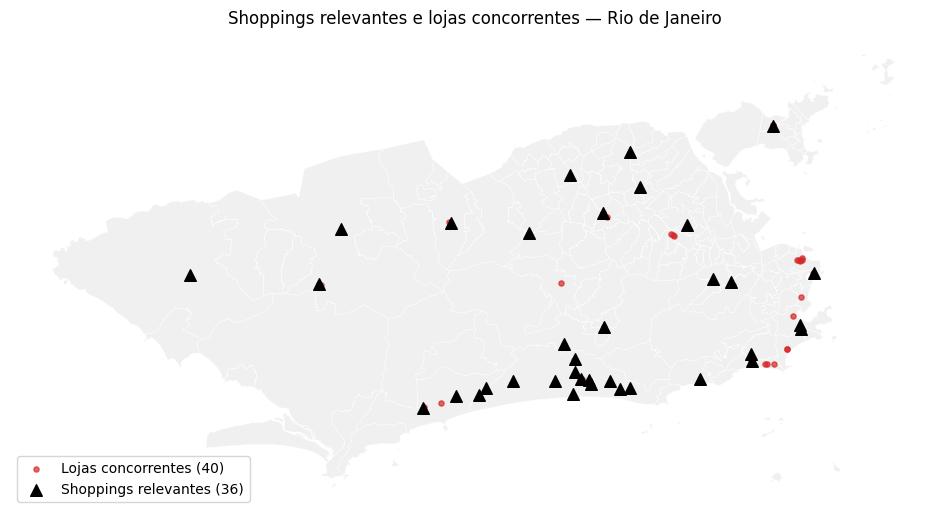

Salvo ✅


In [22]:
import math

query_malls2 = f"""
[out:json][timeout:180];
nwr["shop"="mall"]({bbox});
out geom tags;
"""

dados_m2 = None
for tentativa in range(4):
    for srv in servidores:
        try:
            r = requests.post(srv, data={"data": query_malls2}, headers=headers, timeout=240)
            print(f"Tentativa {tentativa+1} | {srv} → Status: {r.status_code}")
            if r.status_code == 200:
                dados_m2 = r.json()
                break
        except Exception as e:
            print(srv, "→ erro:", e)
    if dados_m2:
        break
    time.sleep(15 * (tentativa + 1))

if not dados_m2:
    raise RuntimeError("Nenhum servidor respondeu. Espere alguns minutos e execute de novo.")

def area_m2(el):
    b = el.get("bounds")
    if not b:
        return 0.0
    lat_m = (b["maxlat"] - b["minlat"]) * 111320
    lon_m = (b["maxlon"] - b["minlon"]) * 111320 * math.cos(math.radians((b["maxlat"] + b["minlat"]) / 2))
    return lat_m * lon_m

linhas = []
for el in dados_m2["elements"]:
    b = el.get("bounds")
    if b:
        lat, lon = (b["maxlat"] + b["minlat"]) / 2, (b["maxlon"] + b["minlon"]) / 2
    else:
        lat, lon = el.get("lat"), el.get("lon")
    if lat is None or lon is None:
        continue
    linhas.append({"osm_id": f'{el["type"]}/{el["id"]}',
                   "nome": el.get("tags", {}).get("name", ""),
                   "area_m2": area_m2(el), "lat": lat, "lon": lon})

m = gpd.GeoDataFrame(linhas,
      geometry=gpd.points_from_xy([l["lon"] for l in linhas], [l["lat"] for l in linhas]),
      crs=4326).to_crs(rio_dados.crs)
m = gpd.sjoin(m, rio_dados[["CD_BAIRRO", "NM_BAIRRO", "geometry"]],
              how="inner", predicate="within").drop(columns="index_right")
m = m.drop_duplicates(subset=["nome", "NM_BAIRRO"]).reset_index(drop=True)
print("\nRegistros shop=mall no município:", len(m))

excluir_nome = (r"galeria|centro comercial|edif|mercado|terminal|condom|estacionamento|office|"
                r"m[eé]dico|polo t|galp[aã]o|assist|tombado|inform[aá]tica|popular|espa[cç]o|"
                r"expans[aã]o|promoinfo|infoland|infomix|trade center")
LIMITE_M2 = 15000

sem_nome = m["nome"].str.strip() == ""
nome_ruim = m["nome"].str.contains(excluir_nome, case=False, regex=True, na=False)
pequeno = m["area_m2"] < LIMITE_M2

relevantes = m[~sem_nome & ~nome_ruim & ~pequeno].copy()
print(f"Sem nome: {sem_nome.sum()} | Nome descartado: {nome_ruim.sum()} | "
      f"Abaixo de {LIMITE_M2:,} m²: {(pequeno & ~sem_nome & ~nome_ruim).sum()}")
print(f"\nShoppings relevantes: {len(relevantes)}")
print(relevantes.sort_values("area_m2", ascending=False)
      [["nome", "NM_BAIRRO", "area_m2"]].round(0).to_string(index=False))

print("\nMaiores descartados por área (para conferir se algum shopping de verdade ficou de fora):")
desc = m[~sem_nome & ~nome_ruim & pequeno].sort_values("area_m2", ascending=False).head(15)
print(desc[["nome", "NM_BAIRRO", "area_m2"]].round(0).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
rio_dados.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.3)
lojas.plot(ax=ax, color="#d62728", markersize=14, alpha=0.7, label=f"Lojas concorrentes ({len(lojas)})")
relevantes.plot(ax=ax, color="black", marker="^", markersize=70, label=f"Shoppings relevantes ({len(relevantes)})")
ax.legend(loc="lower left")
ax.set_title("Shoppings relevantes e lojas concorrentes — Rio de Janeiro")
ax.axis("off")
plt.show()

relevantes.to_file("saida/shoppings_relevantes.gpkg", driver="GPKG")
relevantes.drop(columns="geometry").to_csv("saida/shoppings_relevantes.csv", index=False)
print("Salvo ✅")

In [23]:
import pandas as pd
import geopandas as gpd


lojas_calc = lojas.copy()
lojas_calc["tipo_concorrencia"] = "Loja Isolada"
lojas_calc["peso_competitivo"] = 1

shoppings_calc = relevantes.copy()
shoppings_calc["tipo_concorrencia"] = "Shopping Center"
shoppings_calc["peso_competitivo"] = 3

cols = ["geometry", "NM_BAIRRO", "tipo_concorrencia", "peso_competitivo"]

if "NM_BAIRRO" not in lojas_calc.columns:
    lojas_calc = gpd.sjoin(lojas_calc, rio_dados[["NM_BAIRRO", "geometry"]], how="inner", predicate="within")

concorrencia = pd.concat([lojas_calc[cols], shoppings_calc[cols]], ignore_index=True)
concorrencia = gpd.GeoDataFrame(concorrencia, geometry="geometry", crs=rio_dados.crs)

cobertura_bairro = concorrencia.groupby("NM_BAIRRO")["peso_competitivo"].sum().reset_index()
cobertura_bairro = cobertura_bairro.sort_values("peso_competitivo", ascending=False)

print(f"Total de polos competitivos na base: {len(concorrencia)} (Shoppings + Lojas Isoladas)")
print(f"Bairros cobertos com concorrência: {len(cobertura_bairro)} de {len(rio_dados)}")
print("\nTop 10 Bairros com Maior Força Competitiva:")
print(cobertura_bairro.head(10).to_string(index=False))

concorrencia.to_file("saida/concorrencia_unificada.gpkg", driver="GPKG")
print("\nSalvo ✅ saida/concorrencia_unificada.gpkg")

Total de polos competitivos na base: 76 (Shoppings + Lojas Isoladas)
Bairros cobertos com concorrência: 26 de 162

Top 10 Bairros com Maior Força Competitiva:
               NM_BAIRRO  peso_competitivo
         Barra da Tijuca                38
Recreio dos Bandeirantes                14
                  Centro                 9
            Campo Grande                 9
                Botafogo                 8
             Jacarepaguá                 6
               Madureira                 6
          Jardim Carioca                 5
                   Bangu                 4
                    Anil                 4

Salvo ✅ saida/concorrencia_unificada.gpkg


🎯 TOP 12 OPORTUNIDADES (WHITE SPOTS) NO RIO DE JANEIRO:
        NM_BAIRRO  score_white_spot    dens_alvo  saturacao_2km
          Rocinha              92.5 26015.552633            3.0
             Maré              72.9 14252.113166            0.0
      Jacarezinho              72.2 17217.448248            3.0
          Estácio              68.7 12433.043231            0.0
           Catete              63.4 15583.085709            5.0
   Cidade de Deus              61.3  9256.584822            0.0
            Acari              60.8  9006.630370            0.0
          Catumbi              60.2  8769.416003            0.0
         Flamengo              60.2 10913.898722            2.0
     Pitangueiras              56.8  7300.711990            0.0
Praia da Bandeira              56.5  7158.684761            0.0
    Vasco da Gama              55.3  6629.970660            0.0


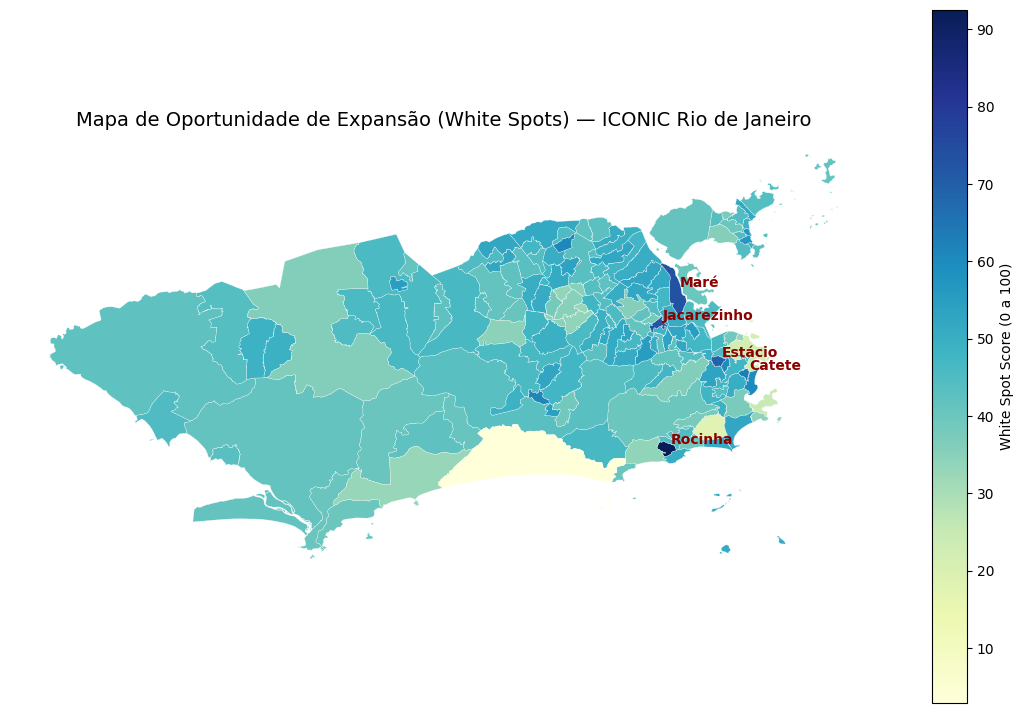


Base final gerada com sucesso! ✅


In [24]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import geopandas as gpd


bairros_raio = rio_dados[['CD_BAIRRO', 'NM_BAIRRO', 'geometry']].copy()
bairros_raio['geometry'] = bairros_raio.geometry.centroid.buffer(2000)


concorrencia_raio = gpd.sjoin(concorrencia, bairros_raio, how="inner", predicate="within")

saturacao = concorrencia_raio.groupby('CD_BAIRRO')['peso_competitivo'].sum().reset_index()
saturacao.rename(columns={'peso_competitivo': 'saturacao_2km'}, inplace=True)

rio_dados = rio_dados.merge(saturacao, on='CD_BAIRRO', how='left')
rio_dados['saturacao_2km'] = rio_dados['saturacao_2km'].fillna(0)


scaler = MinMaxScaler()
rio_dados[['dens_alvo_norm', 'saturacao_norm']] = scaler.fit_transform(rio_dados[['dens_alvo', 'saturacao_2km']])


rio_dados['score_white_spot'] = (rio_dados['dens_alvo_norm'] * 0.6) + ((1 - rio_dados['saturacao_norm']) * 0.4)
rio_dados['score_white_spot'] = (rio_dados['score_white_spot'] * 100).round(1)

top_spots = rio_dados.sort_values('score_white_spot', ascending=False).head(12)
print("🎯 TOP 12 OPORTUNIDADES (WHITE SPOTS) NO RIO DE JANEIRO:")
print(top_spots[['NM_BAIRRO', 'score_white_spot', 'dens_alvo', 'saturacao_2km']].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 9))
rio_dados.plot(column="score_white_spot", cmap="YlGnBu", legend=True,
               edgecolor="white", linewidth=0.2, ax=ax,
               legend_kwds={"label": "White Spot Score (0 a 100)", "orientation": "vertical"})

for idx, row in top_spots.head(5).iterrows():
    ax.annotate(row['NM_BAIRRO'],
                xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                xytext=(3, 3), textcoords="offset points",
                fontsize=10, fontweight='bold', color='darkred')

ax.set_title("Mapa de Oportunidade de Expansão (White Spots) — ICONIC Rio de Janeiro", fontsize=14)
ax.axis("off")
plt.show()

rio_dados.to_file("saida/white_spots_final.gpkg", driver="GPKG")
print("\nBase final gerada com sucesso! ✅")

In [25]:
from google.colab import files

rio_dados['Latitude'] = rio_dados.geometry.centroid.y
rio_dados['Longitude'] = rio_dados.geometry.centroid.x

cols_dash = {
    'NM_BAIRRO': 'Bairro',
    'Latitude': 'Latitude',
    'Longitude': 'Longitude',
    'pop_total': 'População Total',
    'pop_alvo_20_49': 'Público-Alvo (20-49 anos)',
    'dens_alvo': 'Densidade Público-Alvo',
    'saturacao_2km': 'Saturação Competitiva',
    'score_white_spot': 'Score White Spot (MPI)'
}

df_looker = rio_dados[cols_dash.keys()].rename(columns=cols_dash).copy()

df_looker = df_looker.sort_values('Score White Spot (MPI)', ascending=False)

caminho_csv = "dados_looker_studio.csv"
df_looker.to_csv(caminho_csv, index=False)
files.download(caminho_csv)
print("Download concluído! Arquivo pronto para o Looker Studio.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download concluído! Arquivo pronto para o Looker Studio.


In [27]:
import folium
from google.colab import files

mapa_interativo = folium.Map(location=[-22.9068, -43.1729], zoom_start=11, tiles="CartoDB positron")

spots_viaveis = rio_dados[rio_dados['score_white_spot'] > 0].copy()

for idx, row in spots_viaveis.iterrows():
    lat = row['geometry'].centroid.y
    lon = row['geometry'].centroid.x
    score = row['score_white_spot']
    bairro = row['NM_BAIRRO']

    is_top = row['NM_BAIRRO'] in top_spots['NM_BAIRRO'].values
    cor = 'darkred' if is_top else 'steelblue'
    raio = 12 if is_top else 5

    popup_text = f"""
    **{bairro}**

    Score MPI: {score}


Público-Alvo: {int(row['pop_alvo_20_49'])} hab

Saturação (2km): {int(row['saturacao_2km'])} lojas
"""

folium.CircleMarker(
    location=[lat, lon],
    radius=raio,
    color=cor,
    fill=True,
    fill_opacity=0.7,
    popup=folium.Popup(popup_text, max_width=250),
    tooltip=f"{bairro} (Score: {score})"
).add_to(mapa_interativo)

mapa_interativo.save("index.html")
files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>